In [2]:
import pickle as pkl
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

"""Plot setup"""
sns.set_style("whitegrid")
sns.set_color_codes(palette="colorblind")

plt.rcParams.update({
	"text.usetex": False,  # keep False to avoid requiring a LaTeX installation
	"mathtext.fontset": "cm",  # Computer Modern (LaTeX-like)
	"font.family": "serif",
	"font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 14,      # increase axis label size
    "axes.titlesize": 16,
    "xtick.labelsize": 14,     # increase tick / bin label size
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

OUTPUT_DIR = Path.cwd().parent / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

# Parameter Estimation Notebook

Daniel Krawciw

## Population System

In [ ]:
with open(OUTPUT_DIR / "parameter_estimation_predator_prey.pkl", "rb") as f:
    plotting_obj = pkl.load(f)

trajectory_residual_obj = plotting_obj["trajectory_residual_obj"]
derivative_residual_obj = plotting_obj["derivative_residual_obj"]

num_frames_list = trajectory_residual_obj["num_frames_list"]
epochs_list = trajectory_residual_obj["epochs_list"]

trajectory_frame_samples = trajectory_residual_obj["frame_samples_trajectory"]
trajectory_epoch_samples = trajectory_residual_obj["epoch_samples_trajectory"]

derivative_frame_samples = derivative_residual_obj["frame_samples_trajectory"]
derivative_epoch_samples = derivative_residual_obj["epoch_samples_trajectory"]

### Epoch Comparison

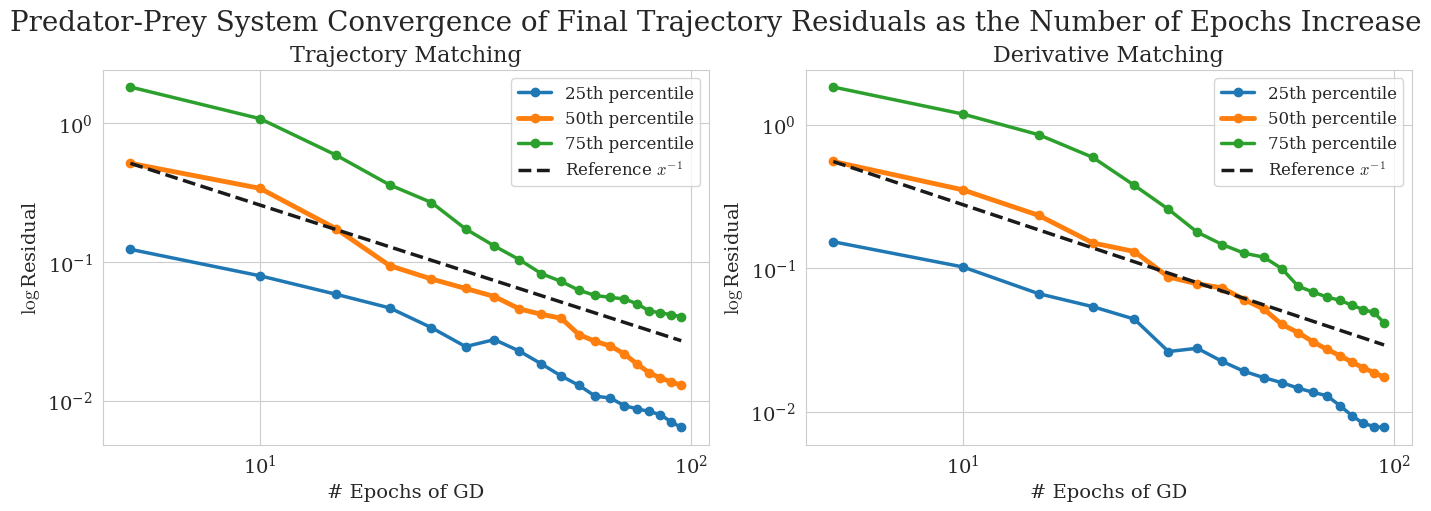

In [18]:
epochs = epochs_list
trajectory_samples = trajectory_epoch_samples
derivative_samples = derivative_epoch_samples
# cascade_samples = results["cascade"]['trajectory_residual']

x = np.array(epochs, dtype=float)

trajectory_samples = np.array(trajectory_samples, dtype=float)
derivative_samples = np.array(derivative_samples, dtype=float)

plot_data = [
    ("Trajectory Matching", trajectory_samples),
    ("Derivative Matching", derivative_samples),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (title, samples) in zip(axes, plot_data):
    q25 = np.percentile(samples, 25, axis=1)
    q50 = np.percentile(samples, 50, axis=1)
    q75 = np.percentile(samples, 75, axis=1)

    ax.loglog(x, q25, marker="o", linewidth=2.5, label="25th percentile")
    ax.loglog(x, q50, marker="o", linewidth=3.5, label="50th percentile")
    ax.loglog(x, q75, marker="o", linewidth=2.5, label="75th percentile")

    reference = q50[0] * (x[0] / x)
    ax.loglog(x, reference, "k--", linewidth=2.5, label=r"Reference $x^{-1}$")

    ax.set_title(title)
    ax.set_xlabel("# Epochs of GD")
    ax.set_ylabel(r"$\log$Residual")
    ax.legend()

fig.suptitle("Predator-Prey System Convergence of Final Trajectory Residuals as the Number of Epochs Increase", fontsize=20)
plt.savefig(OUTPUT_DIR / "populationsystem_residual_methods_percentiles_by_epochs.svg")
plt.show()

### Frames Comparison

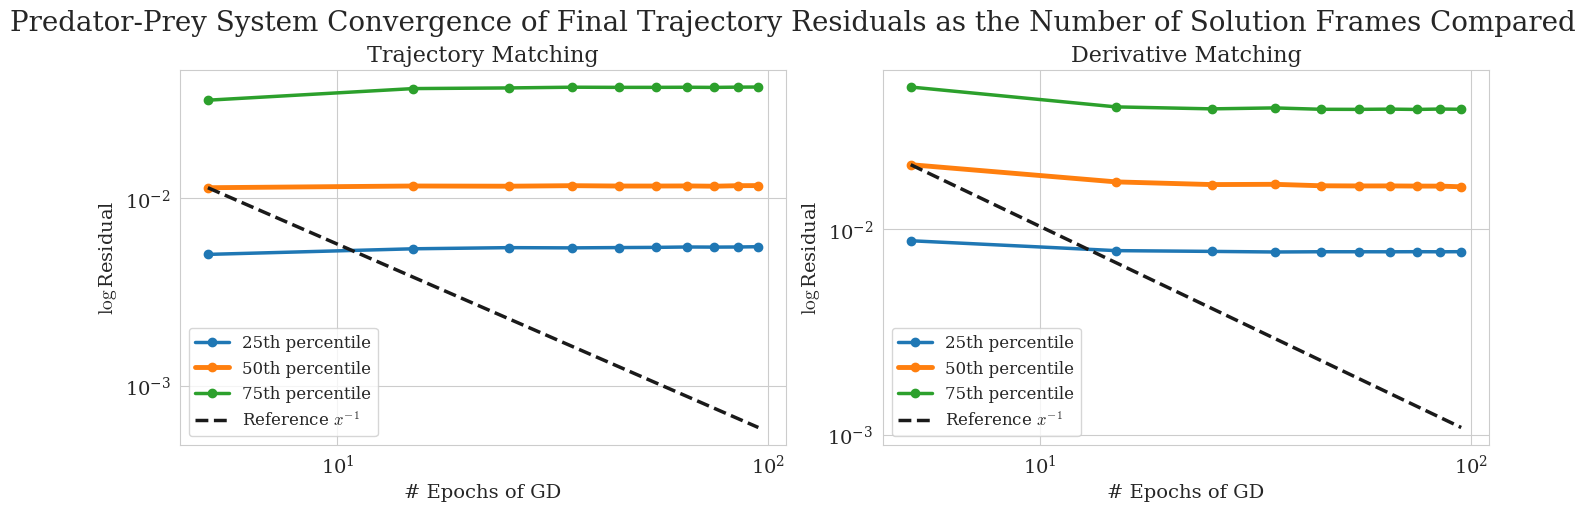

In [19]:
num_frames_list = num_frames_list
trajectory_samples = trajectory_frame_samples
derivative_samples = derivative_frame_samples

x = np.array(num_frames_list, dtype=float)

trajectory_samples = np.array(trajectory_samples, dtype=float)
derivative_samples = np.array(derivative_samples, dtype=float)

plot_data = [
    ("Trajectory Matching", trajectory_samples),
    ("Derivative Matching", derivative_samples),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (title, samples) in zip(axes, plot_data):
    q25 = np.percentile(samples, 25, axis=1)
    q50 = np.percentile(samples, 50, axis=1)
    q75 = np.percentile(samples, 75, axis=1)

    ax.loglog(x, q25, marker="o", linewidth=2.5, label="25th percentile")
    ax.loglog(x, q50, marker="o", linewidth=3.5, label="50th percentile")
    ax.loglog(x, q75, marker="o", linewidth=2.5, label="75th percentile")

    reference = q50[0] * (x[0] / x)
    ax.loglog(x, reference, "k--", linewidth=2.5, label=r"Reference $x^{-1}$")

    ax.set_title(title)
    ax.set_xlabel("# Epochs of GD")
    ax.set_ylabel(r"$\log$Residual")
    ax.legend()

# fig.suptitle("Residual Percentiles vs Number of Observed Frames", fontsize=20)
fig.suptitle("Predator-Prey System Convergence of Final Trajectory Residuals as the Number of Solution Frames Compared", fontsize=20)
plt.savefig(OUTPUT_DIR / "populationsystem_residual_methods_percentiles_by_frames.svg")
plt.show()

## Advection-Diffusion

In [12]:
with open(OUTPUT_DIR / "parameter_estimation_advection_diffusion.pkl", 'rb') as pkl_file:
    plotting_obj = pkl.load(pkl_file)

trajectory_residual_obj = plotting_obj["trajectory_residual_obj"]
derivative_residual_obj = plotting_obj["derivative_residual_obj"]

num_frames_list = derivative_residual_obj["num_frames_list"]
epochs_list = derivative_residual_obj["epochs_list"]

trajectory_frame_samples = trajectory_residual_obj["frame_samples_trajectory"]
trajectory_epoch_samples = trajectory_residual_obj["epoch_samples_trajectory"]

derivative_frame_samples = derivative_residual_obj["frame_samples_trajectory"]
derivative_epoch_samples = derivative_residual_obj["epoch_samples_trajectory"]

### Residuals as # of Epochs increase

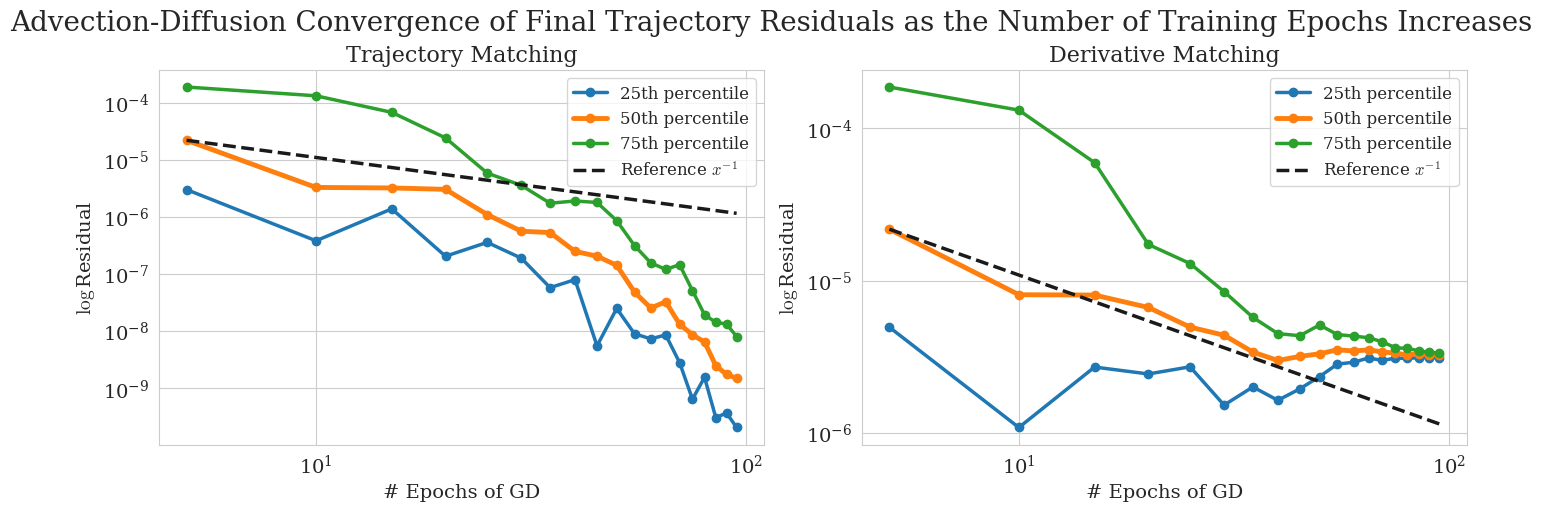

In [13]:
x = np.array(epochs_list, dtype=float)

trajectory_samples = np.array(trajectory_epoch_samples, dtype=float)
derivative_samples = np.array(derivative_epoch_samples, dtype=float)

plot_data = [
    ("Trajectory Matching", trajectory_samples),
    ("Derivative Matching", derivative_samples),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (title, samples) in zip(axes, plot_data):
    q25 = np.percentile(samples, 25, axis=1)
    q50 = np.percentile(samples, 50, axis=1)
    q75 = np.percentile(samples, 75, axis=1)

    ax.loglog(x, q25, marker="o", linewidth=2.5, label="25th percentile")
    ax.loglog(x, q50, marker="o", linewidth=3.5, label="50th percentile")
    ax.loglog(x, q75, marker="o", linewidth=2.5, label="75th percentile")

    reference = q50[0] * (x[0] / x)
    ax.loglog(x, reference, "k--", linewidth=2.5, label=r"Reference $x^{-1}$")

    ax.set_title(title)
    ax.set_xlabel("# Epochs of GD")
    ax.set_ylabel(r"$\log$Residual")
    ax.legend()

# fig.suptitle("Residual Percentiles vs Number of Observed Frames", fontsize=20)
fig.suptitle("Advection-Diffusion Convergence of Final Trajectory Residuals as the Number of Training Epochs Increases", fontsize=20)
plt.savefig(OUTPUT_DIR / "advectiondiffusion_residual_methods_percentiles_by_epochs.svg")
plt.show()

### Residuals as # of Frames Seen Increase

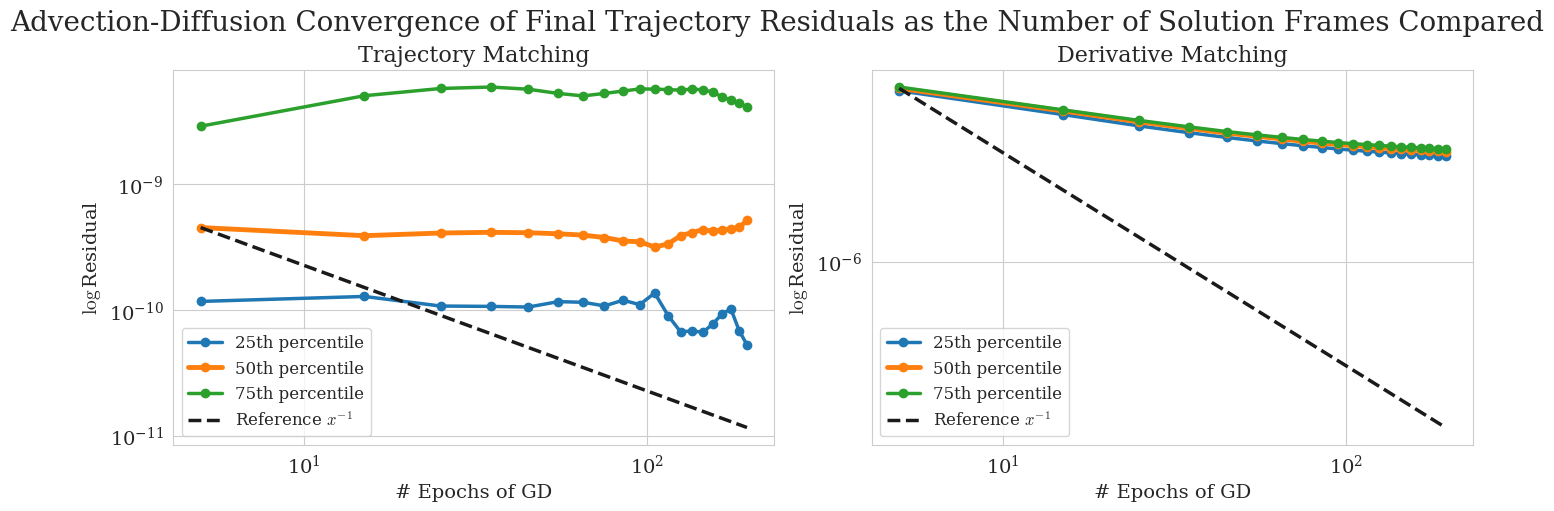

In [14]:
x = np.array(num_frames_list, dtype=float)

trajectory_samples = np.array(trajectory_frame_samples, dtype=float)
derivative_samples = np.array(derivative_frame_samples, dtype=float)

plot_data = [
    ("Trajectory Matching", trajectory_samples),
    ("Derivative Matching", derivative_samples),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (title, samples) in zip(axes, plot_data):
    q25 = np.percentile(samples, 25, axis=1)
    q50 = np.percentile(samples, 50, axis=1)
    q75 = np.percentile(samples, 75, axis=1)

    ax.loglog(x, q25, marker="o", linewidth=2.5, label="25th percentile")
    ax.loglog(x, q50, marker="o", linewidth=3.5, label="50th percentile")
    ax.loglog(x, q75, marker="o", linewidth=2.5, label="75th percentile")

    reference = q50[0] * (x[0] / x)
    ax.loglog(x, reference, "k--", linewidth=2.5, label=r"Reference $x^{-1}$")

    ax.set_title(title)
    ax.set_xlabel("# Epochs of GD")
    ax.set_ylabel(r"$\log$Residual")
    ax.legend()

# fig.suptitle("Residual Percentiles vs Number of Observed Frames", fontsize=20)
fig.suptitle("Advection-Diffusion Convergence of Final Trajectory Residuals as the Number of Solution Frames Compared", fontsize=20)
plt.savefig(OUTPUT_DIR / "advectiondiffusion_residual_methods_percentiles_by_frames.svg")
plt.show()